In [21]:
!pip -q install PyALE

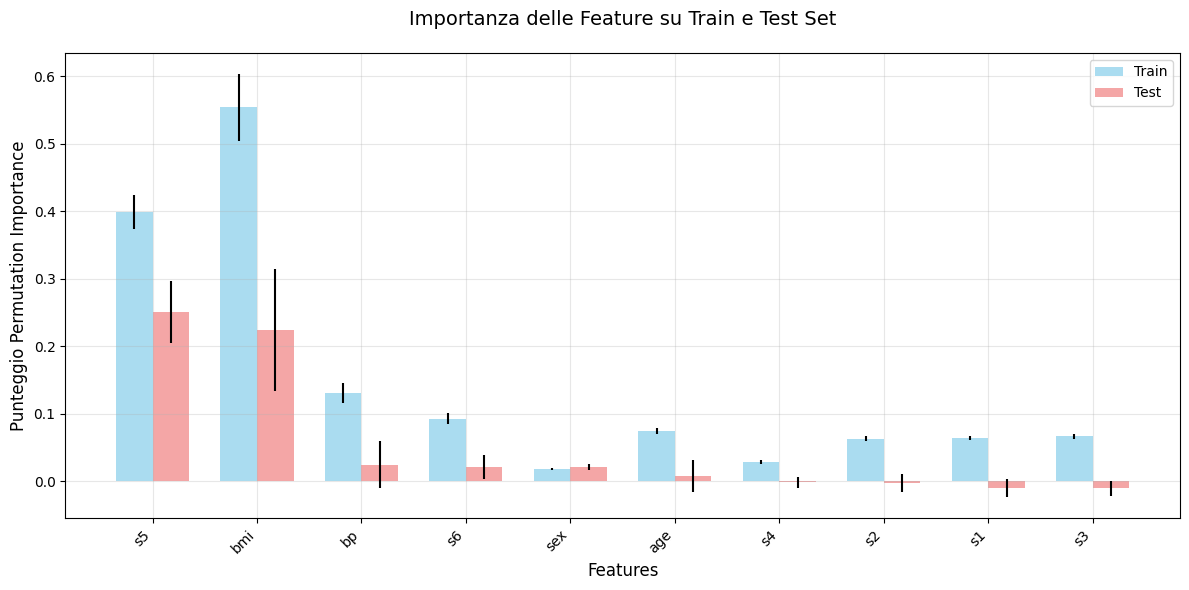

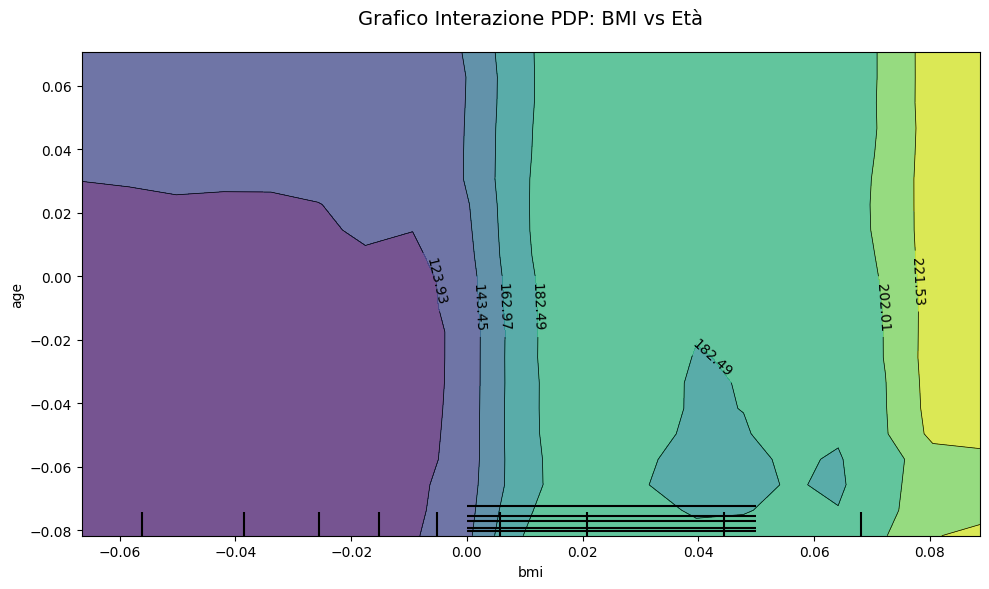

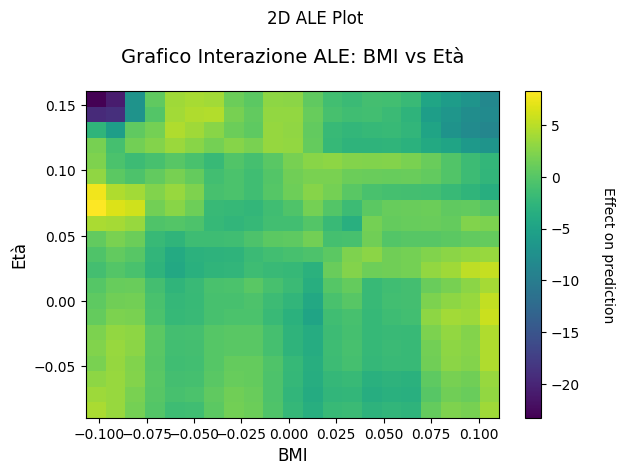


Riepilogo Importanza delle Feature:
Feature  Importanza Train  Std Train  Importanza Test  Std Test
     s5          0.398580   0.025611         0.251169  0.046106
    bmi          0.553955   0.049448         0.224080  0.090849
     bp          0.130177   0.014667         0.024449  0.035230
     s6          0.092734   0.007614         0.021204  0.017603
    sex          0.018196   0.001900         0.020924  0.004319
    age          0.074423   0.004980         0.007844  0.024104
     s4          0.028455   0.002642        -0.001646  0.008055
     s2          0.062755   0.003711        -0.003065  0.012889
     s1          0.063228   0.003030        -0.010535  0.013189
     s3          0.066121   0.003100        -0.010631  0.011179


In [22]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.inspection import PartialDependenceDisplay
import matplotlib.pyplot as plt
import seaborn as sns
from PyALE import ale

# Impostazioni globali per i plot
sns.set_palette("husl")

# Caricamento dei dati
diabetes = load_diabetes()
X = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
y = diabetes.target

# Divisione dei dati in train e test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Addestramento del Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Calcolo della permutation importance per entrambi i set di dati
train_importance = permutation_importance(rf, X_train, y_train, n_repeats=10, random_state=42)
test_importance = permutation_importance(rf, X_test, y_test, n_repeats=10, random_state=42)

# Creazione del DataFrame con i punteggi di importance
importance_df = pd.DataFrame({
    'Feature': diabetes.feature_names,
    'Importanza Train': train_importance.importances_mean,
    'Std Train': train_importance.importances_std,
    'Importanza Test': test_importance.importances_mean,
    'Std Test': test_importance.importances_std
})

# Ordinamento per importanza sul test set
importance_df = importance_df.sort_values('Importanza Test', ascending=False)

# 1. Visualizzazione della permutation importance
plt.figure(figsize=(12, 6))
x = np.arange(len(importance_df))
width = 0.35

plt.bar(x - width/2, importance_df['Importanza Train'], width,
        yerr=importance_df['Std Train'], label='Train', color='skyblue', alpha=0.7)
plt.bar(x + width/2, importance_df['Importanza Test'], width,
        yerr=importance_df['Std Test'], label='Test', color='lightcoral', alpha=0.7)

plt.xlabel('Features', fontsize=12)
plt.ylabel('Punteggio Permutation Importance', fontsize=12)
plt.title('Importanza delle Feature su Train e Test Set', fontsize=14, pad=20)
plt.xticks(x, importance_df['Feature'], rotation=45, ha='right')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# 2. Visualizzazione  del PDP di interazione
fig, ax = plt.subplots(figsize=(10, 6))
features_to_plot = [('bmi', 'age')]  # Lista di tuple per indicare l'interazione
display = PartialDependenceDisplay.from_estimator(
    rf,
    X_train,
    features_to_plot,
    kind='average',
    n_jobs=3,
    grid_resolution=20,
    ax=ax,
    contour_kw={'cmap': 'viridis', 'alpha': 0.75}
)
plt.title('Grafico Interazione PDP: BMI vs Età', fontsize=14, pad=20)
plt.tight_layout()
plt.show()


# 3. Calcolo e visualizzazione dell'interazione ALE
ale_eff = ale(
    X=X_train,
    model=rf,
    feature=['bmi', 'age'],
    grid_size=20,
    include_CI=False
)
plt.xlabel('BMI', fontsize=12)
plt.ylabel('Età', fontsize=12)
plt.title('Grafico Interazione ALE: BMI vs Età', fontsize=14, pad=20)
plt.tight_layout()
plt.show()

# Stampa dei risultati numerici
print("\nRiepilogo Importanza delle Feature:")
print(importance_df.to_string(index=False))